In [2]:
from torch.utils.data import Dataset
from PIL import Image
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import numpy as np
from torch import nn, optim

In [3]:
# traindir = '././data_of_train1/train'

valdir = '././data_of_valid2/test-copy'
# traindir = '././data_of_train1/train'
traindir = '././data_of_train1/train-copy'

# valdir = '././waste/combined_data_mini/val'
# traindir = '././waste/combined_data/train'

train_transforms  = transforms.Compose([
        transforms.Resize(224),
        # transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(p=0.3),#Flip some images randomly
        transforms.RandomPerspective(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
test_transforms = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

train_datasets = datasets.ImageFolder(traindir, train_transforms)# Prepare dataset, folder's name from 0-6 represent 7 emotions
dataset_test = datasets.ImageFolder(valdir, test_transforms)

data_loader = torch.utils.data.DataLoader(
    train_datasets, batch_size=32, shuffle=True, num_workers=3, pin_memory=True)
val_dataloader = torch.utils.data.DataLoader(
    dataset_test, batch_size=32, shuffle=False, num_workers=3, pin_memory=True)

classes = data_loader.dataset.classes
print(classes)

['0', '1', '2', '3', '4', '5', '6']


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = torch.device('cpu')
print(device)

cuda


In [5]:
def he_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [ ]:
# from torchvision import models
# model = models.resnet50(pretrained=True)#Set to ResNet50
# model = models.densenet121(pretrained=True)#Set to DenseNet121
# num_features = model.fc.in_features
# model.fc = torch.nn.Linear(num_features, 7)#Set output channel to7 for classification, set to 2 for valence and arousal

In [6]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample):
        super().__init__()
        if downsample:# if downsample is true, will raise skip connection. will correspond the input and output channels
            self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
            self.shortcut = nn.Sequential()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.drop = nn.Dropout(0.2)

    def forward(self, input):
        shortcut = self.shortcut(input)
        input = nn.ReLU()(self.bn1(self.conv1(input)))
        input = nn.ReLU()(self.bn2(self.conv2(input)))
        # input = self.drop(input)
        input = input + shortcut
        return nn.ReLU()(input)

class ResNet18(nn.Module):
    def __init__(self, in_channels, resblock, outputs=7):
        super().__init__()
        self.layer0 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3),
            # nn.Conv2d(in_channels, 64, kernel_size=3, stride=2, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.layer1 = nn.Sequential(
            resblock(64, 64, downsample=False),
            resblock(64, 64, downsample=False),
            nn.AvgPool2d(2),
        )

        self.layer2 = nn.Sequential(
            resblock(64, 128, downsample=True),
            resblock(128, 128, downsample=False),
            nn.AvgPool2d(2),
        )

        self.layer3 = nn.Sequential(
            resblock(128, 256, downsample=True),
            resblock(256, 256, downsample=False),
            nn.AvgPool2d(2),
        )


        self.layer4 = nn.Sequential(
            resblock(256, 512, downsample=True),
            resblock(512, 512, downsample=False)
        )

        self.gap = torch.nn.AdaptiveAvgPool2d(1)# global average pooliing
        self.classifier = nn.Sequential(
            # nn.AvgPool2d(2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, outputs)
        )

    def forward(self, input):
        input = self.layer0(input)
        input = self.layer1(input)
        input = self.layer2(input)
        input = self.layer3(input)
        input = self.layer4(input)
        input = self.gap(input)
        input = torch.flatten(input, start_dim=1)
        input = self.classifier(input)

        return input

model = ResNet18(3, ResBlock, outputs=7)#Set output channel to7 for classification, set to 2 for valence and arousal
model.to(torch.device("cuda:0" if torch.cuda.is_available() else "cpu"))

ResNet18(
  (layer0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
  )
  (layer1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (shortcut): Sequential()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop): Dropout(p=0.2, inplace=False)
    )
    (1): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (shortcut): Sequential()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): Ba

In [9]:
# model.apply(he_init)
lr = 1e-3
weight_decay = 5e-4

loss = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
# optimizer = torch.optim.Adamax(model.parameters(), lr=lr, weight_decay=weight_decay)
# optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, alpha=0.99, eps=1e-08, weight_decay=weight_decay, momentum=momentum)
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(data_loader), epochs=num_epochs)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [10]:
model = model.to(device)
print(next(model.parameters()).device)
print(torch.cuda.is_available())  # Should return True if CUDA is available
print(torch.cuda.current_device())  # Returns the index of the current device
print(torch.cuda.get_device_name(torch.cuda.current_device()))  # Returns the name of the current device

cuda:0
True
0
NVIDIA GeForce RTX 3060 Laptop GPU


Epoch 1: Train Loss = 1.8017, Train F1 = 0.2435, Val Loss = 1.9216, Val F1 = 0.1599
Epoch 2: Train Loss = 1.6753, Train F1 = 0.3255, Val Loss = 1.8121, Val F1 = 0.2443
Epoch 3: Train Loss = 1.5795, Train F1 = 0.3852, Val Loss = 1.7842, Val F1 = 0.2660
Epoch 4: Train Loss = 1.5175, Train F1 = 0.4177, Val Loss = 2.9540, Val F1 = 0.1404
Epoch 5: Train Loss = 1.4684, Train F1 = 0.4405, Val Loss = 2.8785, Val F1 = 0.1287
Epoch 6: Train Loss = 1.4309, Train F1 = 0.4559, Val Loss = 3.3967, Val F1 = 0.1426
Epoch 7: Train Loss = 1.3955, Train F1 = 0.4752, Val Loss = 1.8700, Val F1 = 0.2820
Epoch 8: Train Loss = 1.3690, Train F1 = 0.4843, Val Loss = 3.7977, Val F1 = 0.1654
Epoch 9: Train Loss = 1.3440, Train F1 = 0.4962, Val Loss = 1.9706, Val F1 = 0.2845
Epoch 10: Train Loss = 1.3193, Train F1 = 0.5057, Val Loss = 10.3017, Val F1 = 0.0737
Epoch 11: Train Loss = 1.3020, Train F1 = 0.5150, Val Loss = 5.8741, Val F1 = 0.1567
Epoch 12: Train Loss = 1.2839, Train F1 = 0.5201, Val Loss = 9.4741, Val 

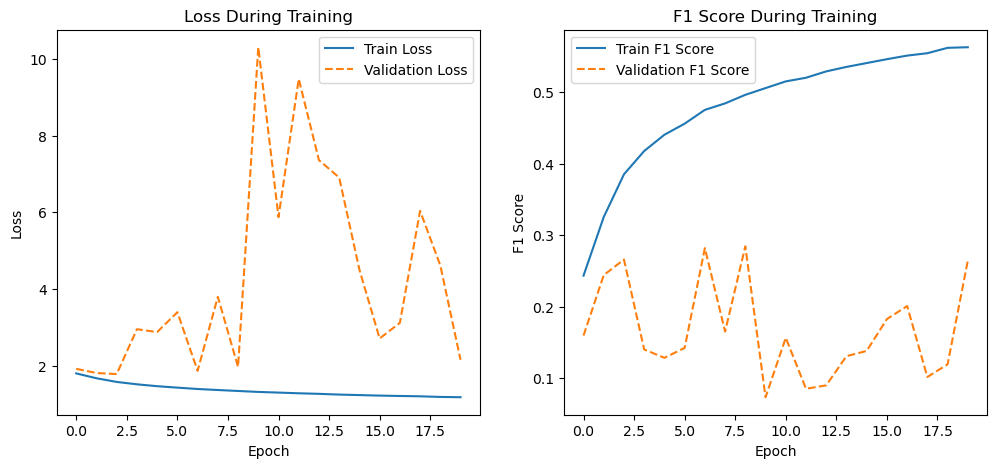

In [13]:
def evaluate_model(model, data_loader):
    model.eval()# Switch model to evaluation mode
    all_labels = []
    all_predictions = []
    total_loss = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)# Move data to cuda
            outputs = model(inputs)
            l = loss(outputs, labels)
            total_loss += l.item()
            _, predicted = torch.max(outputs, 1)# Get the predicted classes
            all_labels.extend(labels.cpu().numpy())# Store true labels
            all_predictions.extend(predicted.cpu().numpy())# Store predictions

    avg_loss = total_loss / len(data_loader)
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    return avg_loss, f1

def train_model(model, train_loader, val_loader, loss, optimizer, epochs=10, lr=0.01):
    train_losses = []
    val_losses = []
    train_f1_scores = []
    val_f1_scores = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        all_labels = []
        all_predictions = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)# Move data to cuda
            optimizer.zero_grad()
            outputs = model(inputs)
            l = loss(outputs, labels)
            l.backward()
            optimizer.step()

            total_loss += l.item()
            _, predicted = torch.max(outputs.data, 1)# Get the predicted classes
            all_labels.extend(labels.cpu().numpy())# Store true labels
            all_predictions.extend(predicted.cpu().numpy())# Store predictions

        train_loss = total_loss / len(train_loader)
        train_f1 = f1_score(all_labels, all_predictions, average='weighted')

        val_loss, val_f1 = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_f1_scores.append(train_f1)
        val_losses.append(val_loss)
        val_f1_scores.append(val_f1)

        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Train F1 = {train_f1:.4f}, Val Loss = {val_loss:.4f}, Val F1 = {val_f1:.4f}")

    return train_losses, train_f1_scores, val_losses, val_f1_scores

def plot_metrics(train_losses, train_f1_scores, val_losses, val_f1_scores):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title('Loss During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_f1_scores, label='Train F1 Score')
    plt.plot(val_f1_scores, label='Validation F1 Score', linestyle='--')
    plt.title('F1 Score During Training')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.show()

train_losses, train_f1_scores, val_losses, val_f1_scores = train_model(model, data_loader, val_dataloader, loss, optimizer, epochs=20, lr=0.0001)
plot_metrics(train_losses, train_f1_scores, val_losses, val_f1_scores)
